100%|██████████| 170M/170M [00:03<00:00, 43.7MB/s]


training started...
epoch 1, loss: 1174.644
epoch 2, loss: 924.885
epoch 3, loss: 811.968
training done
accuracy: 64.38


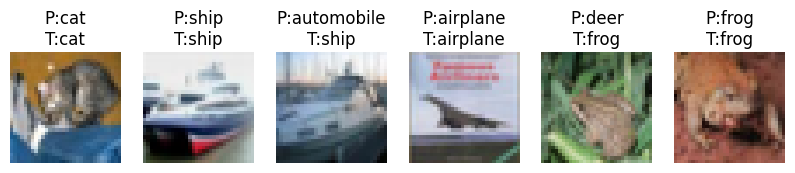

In [1]:
# simple CNN for image classification (CIFAR-10)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ------------------ LOAD DATA ------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes


# ------------------ MODEL ------------------

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, 3)
        self.conv2 = nn.Conv2d(16, 32, 3)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(-1, 32 * 6 * 6)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x


model = SimpleCNN()


# ------------------ TRAIN ------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("training started...")

for epoch in range(3):   # keep small for demo
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"epoch {epoch+1}, loss: {running_loss:.3f}")

print("training done")


# ------------------ TEST ------------------

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("accuracy:", 100 * correct / total)


# ------------------ VISUALIZE ------------------

dataiter = iter(testloader)
images, labels = next(dataiter)

outputs = model(images)
_, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 6, figsize=(10, 3))

for i in range(6):
    img = images[i] / 2 + 0.5   # unnormalize
    npimg = img.numpy()

    axes[i].imshow(np.transpose(npimg, (1, 2, 0)))
    axes[i].set_title(f"P:{classes[preds[i]]}\nT:{classes[labels[i]]}")
    axes[i].axis("off")

plt.show()